In [1]:
# filename = 
import geopandas as gpd
import folium
import json
import pandas as pd
import numpy as np
import pickle
from shapely.geometry import Point
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
import pprint
import os
pp = pprint.PrettyPrinter(indent=0)

Assumptions associated with data filtering

In [182]:
contaminants_of_interest = ["PFPeA","PFBA", "PFHxA", "PFBS", "PFOS", "PFOA", "PFHxS", "PFHpA"]
# contaminants_of_interest = ["PFPeA"]
states_i_want_to_exclude = ['AK', 'HI', 'PR', 'VI', 'AS', 'GU', 'NN', 'MP', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10']

# Creating the data of Water Systems and HUC8s

Loading the HUC8 Shape file

In [183]:
cwd = os.getcwd()

# Load shapefile using GeoPandas
shapefile_path = f"{cwd}/source_data_files/HUC8_CONUS/HUC8_US.shp"
gdf = gpd.read_file(shapefile_path)

# Reproject to WGS84 (lat/lon)
gdf = gdf.to_crs(epsg=4326)
gdf = gdf[['HUC8','geometry', 'NAME']]


Load the PWS geospatial and detection data

In [184]:
# PWS Geospatial Data
pws_geolocations = pd.read_csv(f"{cwd}/source_data_files/generated-data-files/representative_pws_geolocations.csv", header=0)
print("Shape of PWS geolocations data:", pws_geolocations.shape, "with unique PWSIDs:", pws_geolocations.PWSID.nunique())
print("Columnames in PWS geolocations data:", pws_geolocations.columns)
# PWS detection data
ucmr_all_file_path = f"{cwd}/source_data_files/UCMR-data-Oct-2024/UCMR5_All.txt"
ucmr_all_df = pd.read_csv(ucmr_all_file_path, sep='\t', header=0)
print("Shape of UCMR5 data:", ucmr_all_df.shape, "with unique PWSIDs:", ucmr_all_df.PWSID.nunique())

# Filter UCMR5 data for contaminants of interest and then for Contiguous United States
ucmr_filtered_df = ucmr_all_df[ucmr_all_df['Contaminant'].isin(contaminants_of_interest)]
print("Shape of UCMR5 data after filtering for contaminants of interest:", ucmr_filtered_df.PWSID.nunique(), " unique PWSIDs.\nNumber of PWSIDs that did not report a contaminant of interest:", ucmr_all_df.PWSID.nunique() - ucmr_filtered_df.PWSID.nunique())
ucmr_filtered_df = ucmr_filtered_df[ucmr_filtered_df['State'].isin(states_i_want_to_exclude) == False]
print("Shape of UCMR5 data after filtering for Contiguous United States:", ucmr_filtered_df.PWSID.nunique(), "unique PWSIDs.")
print("Column Names in UCMR5 data after filtering:", ucmr_filtered_df.columns)

Shape of PWS geolocations data: (9696, 4) with unique PWSIDs: 9696
Columnames in PWS geolocations data: Index(['PWSID', 'latitude', 'longitude', 'state'], dtype='object')
Shape of UCMR5 data: (1133967, 24) with unique PWSIDs: 7237
Shape of UCMR5 data after filtering for contaminants of interest: 7168  unique PWSIDs.
Number of PWSIDs that did not report a contaminant of interest: 69
Shape of UCMR5 data after filtering for Contiguous United States: 6967 unique PWSIDs.
Column Names in UCMR5 data after filtering: Index(['PWSID', 'PWSName', 'Size', 'FacilityID', 'FacilityName',
       'FacilityWaterType', 'SamplePointID', 'SamplePointName',
       'SamplePointType', 'AssociatedFacilityID', 'AssociatedSamplePointID',
       'CollectionDate', 'SampleID', 'Contaminant', 'MRL', 'Units', 'MethodID',
       'AnalyticalResultsSign', 'AnalyticalResultValue', 'SampleEventCode',
       'MonitoringRequirement', 'Region', 'State', 'UCMR1SampleType'],
      dtype='object')


In [185]:
pws_without_geolocation = []
pws_detects = ucmr_filtered_df[ucmr_filtered_df["AnalyticalResultsSign"]=="="][["PWSID", "Contaminant"]]
pws_detects_df = pd.DataFrame(pws_detects.groupby("PWSID")["Contaminant"].apply(list)).reset_index()
for index, row in pws_detects_df.iterrows():
    geolocation = pws_geolocations[pws_geolocations["PWSID"] == row["PWSID"]][["latitude", "longitude"]].values
    if geolocation.size == 0:
        pws_without_geolocation.append(row["PWSID"])
        pws_detects_df.at[index, "HUC8"] = np.nan
        continue
    else:
        latitude, longitude = geolocation[0]
        point = Point(longitude, latitude)
        pws_detects_df.at[index, "geometry"] = point
        matching_huc8 = gdf[gdf.geometry.contains(point)]
        pws_detects_df.at[index, "HUC8"] = matching_huc8["HUC8"].values[0] if not matching_huc8.empty else None
print("Shape of PWS detects data:", pws_detects_df.shape, "with unique PWSIDs:", pws_detects_df.PWSID.nunique())
print("Of which NaN HUC8:", pws_detects_df[pws_detects_df["HUC8"].isna()].shape[0])
print("Column Names:", pws_detects_df.columns)

pws_non_detects = ucmr_filtered_df[ucmr_filtered_df["PWSID"].isin(pws_detects_df["PWSID"]) == False]
pws_non_detects_df = pd.DataFrame(pws_non_detects.groupby("PWSID")["Contaminant"].apply(list)).reset_index()
for index, row in pws_non_detects_df.iterrows():
    geolocation = pws_geolocations[pws_geolocations["PWSID"] == row["PWSID"]][["latitude", "longitude"]].values
    if geolocation.size == 0:
        pws_without_geolocation.append(row["PWSID"])
        pws_non_detects_df.at[index, "HUC8"] = np.nan
        continue
    else:
        latitude, longitude = geolocation[0]
        point = Point(longitude, latitude)
        pws_non_detects_df.at[index, "geometry"] = point
        matching_huc8 = gdf[gdf.geometry.contains(point)]
        pws_non_detects_df.at[index, "HUC8"] = matching_huc8["HUC8"].values[0] if not matching_huc8.empty else None
print("\nShape of PWS non-detects data:", pws_non_detects_df.shape, "with unique PWSIDs:", pws_non_detects_df.PWSID.nunique())
print("of which Nan HUC8:", pws_non_detects_df[pws_non_detects_df["HUC8"].isna()].shape[0])
print("Column Names:", pws_non_detects_df.columns)
print("\n Total Number of PWSIDs without geolocation, pws_without_geolocation:", len(pws_without_geolocation))

Shape of PWS detects data: (2307, 4) with unique PWSIDs: 2307
Of which NaN HUC8: 51
Column Names: Index(['PWSID', 'Contaminant', 'geometry', 'HUC8'], dtype='object')

Shape of PWS non-detects data: (4660, 4) with unique PWSIDs: 4660
of which Nan HUC8: 161
Column Names: Index(['PWSID', 'Contaminant', 'geometry', 'HUC8'], dtype='object')

 Total Number of PWSIDs without geolocation, pws_without_geolocation: 212


In [186]:
df_of_huc8_with_detections = pws_detects_df[pws_detects_df["HUC8"].notna()][["HUC8", "Contaminant"]]
print("\nShape of df_of_huc8_with_detections:", df_of_huc8_with_detections.shape)

df_of_huc8_with_atleast_one_non_detections = pws_non_detects_df[pws_non_detects_df["HUC8"].notna()][["HUC8", "Contaminant"]]
# df_of_huc8_with_atleast_one_non_detections
df_of_huc8_with_all_non_detects = df_of_huc8_with_atleast_one_non_detections[df_of_huc8_with_atleast_one_non_detections["HUC8"].isin(df_of_huc8_with_detections["HUC8"]) == False]
print("\nShape of df_of_huc8_with_all_non_detects:", df_of_huc8_with_all_non_detects.shape)



Shape of df_of_huc8_with_detections: (2256, 2)

Shape of df_of_huc8_with_all_non_detects: (1723, 2)


# Loading the Data about the NAICS geolocations


#### Start by first loading the EPA-NAICS geolocations data

In [187]:
epa_naics_geolocations = pd.read_csv(f"{cwd}/source_data_files/Facilities-coordinates/EPA-NAICS-Geolocations.csv")
prefix2 = f"{cwd}/source_data_files/Facilities-coordinates/"
airports = pickle.load(open(f"{prefix2}major_airport_coordinates.pkl", "rb"))
military_bases = pickle.load(open(f"{prefix2}military_coordinates.pkl", "rb"))
fire_stations = pickle.load(open(f"{prefix2}fire-training-coordinates.pkl", "rb"))

#### We start by looking at all the NAICS codes that the Presumptive Contamination Paper suggested, and then filter out the top 24 (i.e. the ones with count >500)

In [188]:
naics_codes_csv = pd.read_csv("/Users/pg13/Documents/Personal-Projects/PFAS-Project/source_data_files/Extras/naics.csv")
us_naics_codes = naics_codes_csv[~naics_codes_csv['notes'].isin(('CAN','MEX'))]
six_digit_us_naics_codes = us_naics_codes[us_naics_codes['code'].astype(str).str.len() == 6]
us_manufacturing_naics_codes = six_digit_us_naics_codes[six_digit_us_naics_codes['code'].astype(str).str.startswith(('31', '32', '33'))]
print("Shape of US manufacturing NAICS codes:", us_manufacturing_naics_codes.shape)
us_manufacturing_naics_codes_list = us_manufacturing_naics_codes['code'].tolist()

Shape of US manufacturing NAICS codes: (136, 4)


In [189]:
naics_code_echo = pd.read_excel("/Users/pg13/Documents/Personal-Projects/PFAS-Project/source_data_files/PFASHandlingIndustrySectors-Apr2023-Pub.xlsx", sheet_name="Industries of Interest", header=0)
olem_naics_codes = naics_code_echo[naics_code_echo["OLEM list"]=="Y"]["2017 NAICS Code"].dropna().drop_duplicates().astype(int).tolist()
OAR_naics_codes = naics_code_echo[naics_code_echo["OAR list"]=="Y"]["2017 NAICS Code"].dropna().drop_duplicates().astype(int).tolist()
OECA_naics_codes = naics_code_echo[naics_code_echo["OECA Research"]=="Y"]["2017 NAICS Code"].dropna().drop_duplicates().astype(int).tolist()
MN_naics_codes = naics_code_echo[naics_code_echo["MN List"]=="Y"]["2017 NAICS Code"].dropna().drop_duplicates().astype(int).tolist()
echo_naics_codes = naics_code_echo["2017 NAICS Code"].dropna().drop_duplicates().astype(int).tolist()
chemical_industry_naics_codes = [325110, 325120, 325130, 325180, 325193, 325194, 325199] #325211, 325212, 325221, 325311, 325320, 325411, 325412, 325510, 325611, 325612, 325998]

In [190]:
naics_codes = [
    313320, 325510, 322220, 313210, 322121, 332813, 324110, 325612,
    334413, 326113, 332812, 333318, 334419, 562212, 325199, 323111,
    313110, 314110, 316110, 325211, 324191, 325998, 562211, 562213,
    313310, 322219, 323120, 313220, 313230, 322130, 332999, 424690,
    314910, 326112, 335999, 562112, 562219, 325611
]
# naics_codes = chemical_industry_naics_codes
# naics_codes = us_manufacturing_naics_codes_list 
naics_points = []
for naics_code in naics_codes:
    naics_code_xy_df = epa_naics_geolocations[epa_naics_geolocations['naics_code'] == naics_code].reset_index(drop=True)
    naics_code_xy_data = naics_code_xy_df[['latitude83', 'longitude83']].dropna(axis=0, how='any').reset_index(drop=True)
    unique_xy_data = []
    seen = set()

    for lst in naics_code_xy_data.values:
        t = tuple(lst)  # Convert to tuple (hashable)
        if t not in seen:
            seen.add(t)
            unique_xy_data.append(lst)
    naics_points.append(len(unique_xy_data))

naics_count_df = pd.DataFrame({"NAICS_CODE": naics_codes, "COUNT": naics_points})
naics_count_df.sort_values(by="COUNT", ascending=False, inplace=True)
naics_count_df.reset_index(drop=True, inplace=True) 
NAICS_CODES_OF_INTEREST = naics_count_df[naics_count_df["COUNT"]>=500]['NAICS_CODE'].tolist()

In [191]:
# len(naics_count_df[naics_count_df["COUNT"]>=500]['NAICS_CODE'].tolist())

#### Next I generate the XY data for the 24 NAICS codes

In [192]:
industry_xy_data = []
for naics_code in tqdm(NAICS_CODES_OF_INTEREST, desc="Processing NAICS Codes"):
    # print("NAICS code: ", naics_code)
    naics_code_xy_df = epa_naics_geolocations[epa_naics_geolocations['naics_code'] == naics_code].reset_index(drop=True)
    naics_code_xy_data = naics_code_xy_df[['latitude83', 'longitude83']].dropna(axis=0, how='any').reset_index(drop=True)
    unique_xy_data = []
    seen = set()

    for lst in naics_code_xy_data.values:
        t = tuple(lst)  # Convert to tuple (hashable)
        if t not in seen:
            seen.add(t)
            unique_xy_data.append(lst)
    industry_xy_data.append(unique_xy_data)


    if len(naics_code_xy_data) == 0:
        print(f"NAICS code {naics_code} has no geolocations")
        break

Processing NAICS Codes: 100%|██████████| 25/25 [00:00<00:00, 267.77it/s]


#### Next we calculate the total density of industries in every huc8

In [193]:
huc8s_in_ucmr = pd.concat([df_of_huc8_with_detections["HUC8"], df_of_huc8_with_all_non_detects["HUC8"]], ignore_index=True).unique()
gdf_in_ucmr = gdf[gdf['HUC8'].isin(huc8s_in_ucmr)].reset_index(drop=True)

naics_points = []
naics_ids = []
for group_id, group in enumerate(industry_xy_data):
    for lat, lon in group:
        naics_points.append(Point(lon, lat))
        naics_ids.append(NAICS_CODES_OF_INTEREST[group_id])  # optional if you want to retain NAICS group info

gdf_points = gpd.GeoDataFrame({'naics_group': naics_ids}, geometry=naics_points, crs="EPSG:4326")
gdf_polygons = gdf_in_ucmr.to_crs(epsg=4326)
joined = gpd.sjoin(gdf_points, gdf_polygons[['HUC8', 'geometry']], how="left", predicate="within")
huc_industry_count = joined['HUC8'].value_counts().to_dict()

In [194]:
for index, row in gdf_in_ucmr.iterrows():
    huc8 = row['HUC8']
    count = joined[joined['HUC8'] == huc8].shape[0]
    gdf_in_ucmr.at[index, 'Industry_Count'] = count
gdf_in_ucmr

,HUC8,geometry,NAME,Industry_Count
0,11080001,"POLYGON ((-104.18034 36.92065, -104.18082 36.9...",Canadian Headwaters,2.0
1,11080006,"POLYGON ((-103.47124 35.7468, -103.47112 35.74...",Upper Canadian-Ute Reservoir,0.0
2,13020101,"POLYGON ((-105.23391 37.03586, -105.23421 37.0...",Upper Rio Grande,10.0
3,13020201,"POLYGON ((-105.76419 35.79492, -105.76436 35.7...",Rio Grande-Santa Fe,15.0
4,13020203,"POLYGON ((-106.51613 35.36973, -106.51572 35.3...",Rio Grande-Albuquerque,120.0
...,...,...,...,...
1327,07100001,"POLYGON ((-95.85753 44.25894, -95.85703 44.258...",Des Moines Headwaters,14.0
1328,09020103,"POLYGON ((-95.48913 47.24351, -95.48901 47.243...",Otter Tail,34.0
1329,09020303,"POLYGON ((-95.32015 48.20367, -95.31798 48.202...",Red Lake,10.0
1330,09020301,"POLYGON ((-97.00963 47.97229, -97.00765 47.970...",Sandhill-Wilson,18.0


In [195]:
gdf_proj = gdf_in_ucmr.to_crs(epsg=5070)
gdf_in_ucmr_density = []
for index, row in gdf_proj.iterrows():
    count = row['Industry_Count']
    area = row['geometry'].area
    density = count / area if area != 0 else 0
    gdf_in_ucmr.at[index, 'density'] = density
    if row['HUC8'] in df_of_huc8_with_detections.HUC8.unique():
        gdf_in_ucmr.at[index, 'violation_status'] = 1
    else:
        gdf_in_ucmr.at[index, 'violation_status'] = 0


Text(0.5, 0, 'Industry Density')

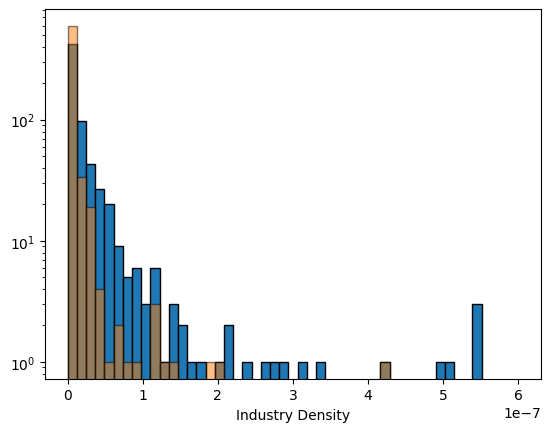

In [196]:
gdf_detects = gdf_in_ucmr[gdf_in_ucmr['HUC8'].isin(df_of_huc8_with_detections['HUC8'].unique())].reset_index(drop=True)
gdf_non_detects = gdf_in_ucmr[gdf_in_ucmr['HUC8'].isin(df_of_huc8_with_all_non_detects['HUC8'].unique())].reset_index(drop=True)

plt.hist(gdf_detects['density'], bins=np.linspace(0,6e-7), edgecolor='black')
plt.hist(gdf_non_detects['density'], bins=np.linspace(0,6e-7), edgecolor='black', alpha=0.5)
plt.yscale('log')
plt.xlabel('Industry Density')   

# MODEL B - Training a 10-fold cross validated Logistic Regression Model on Generic Industrial Density

[[34 25]
 [30 45]]
[[35 29]
 [33 37]]
[[44 24]
 [28 37]]
[[37 27]
 [31 38]]
[[41 28]
 [33 31]]
[[36 33]
 [27 37]]
[[34 31]
 [24 44]]
[[48 23]
 [26 36]]
[[43 28]
 [29 33]]
[[42 24]
 [16 51]]


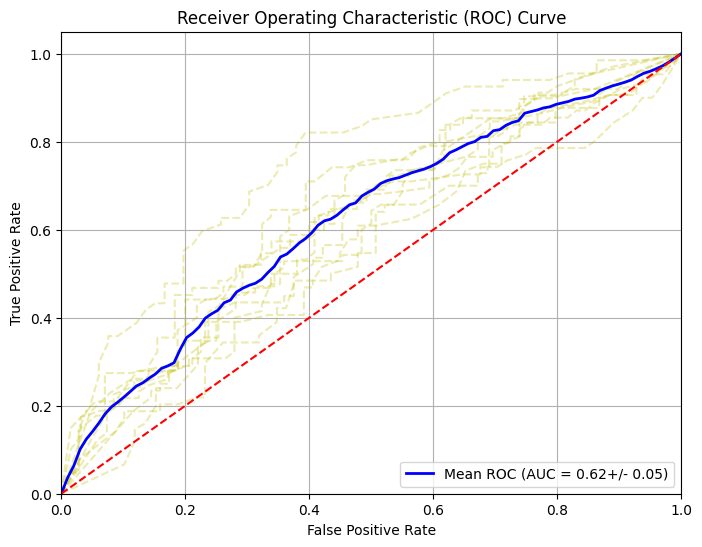

Mean accuracy:  0.5878745370889911 +/- 0.04674697197331933


In [197]:
X = gdf_in_ucmr[['density']].values
y = gdf_in_ucmr['violation_status'].values
kf = KFold(n_splits=10, shuffle=True)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()

roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []

model = RandomForestClassifier()
# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    print(conf_matrix)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_list)

plt.figure(figsize=(8, 6))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))


##### Tuning the threshold

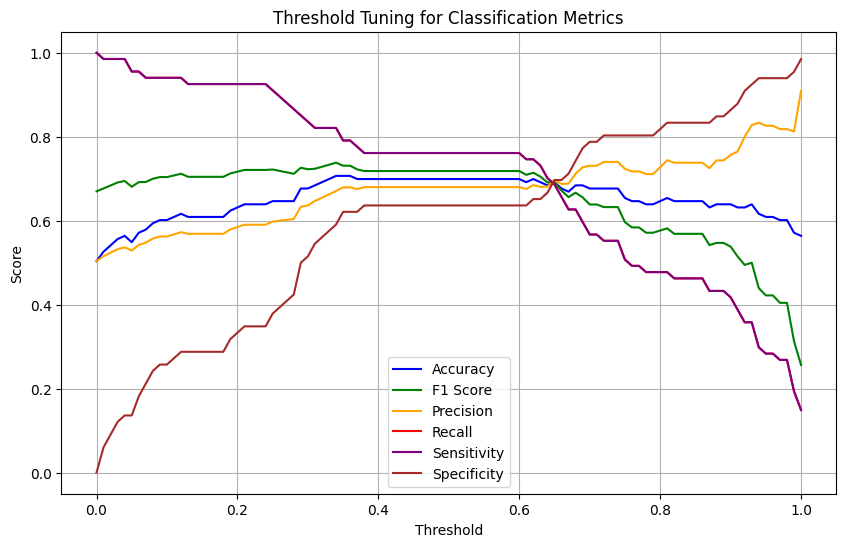

In [198]:
thresholds_for_tuning = np.arange(0.0, 1.01, 0.01)
accuracy_store, f1_score_store, precision_store, recall_store, sensitivity_store, specificity_store = [], [], [], [], [], []
for item in thresholds_for_tuning:
    y_pred_thresholded = (y_pred_proba >= item).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    f1_score = (2 * np.sum(y_test * y_pred_thresholded)) / (np.sum(y_test) + np.sum(y_pred_thresholded))
    precision = np.sum(y_test * y_pred_thresholded) / np.sum(y_pred_thresholded)
    recall = np.sum(y_test * y_pred_thresholded) / np.sum(y_test)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    accuracy_store.append(accuracy)
    f1_score_store.append(f1_score)
    precision_store.append(precision)
    recall_store.append(recall)
    sensitivity_store.append(sensitivity)
    specificity_store.append(specificity)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_for_tuning, accuracy_store, label='Accuracy', color='blue')
plt.plot(thresholds_for_tuning, f1_score_store, label='F1 Score', color='green')
plt.plot(thresholds_for_tuning, precision_store, label='Precision', color='orange')
plt.plot(thresholds_for_tuning, recall_store, label='Recall', color='red')
plt.plot(thresholds_for_tuning, sensitivity_store, label='Sensitivity', color='purple')
plt.plot(thresholds_for_tuning, specificity_store, label='Specificity', color='brown')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Classification Metrics')
plt.legend()
plt.grid()
plt.show()


# Model A- Training a 10-fold cross validated model on just the AFFF users

In [199]:
airports_lat_long = airports[['latitude', 'longitude']].dropna(axis=0, how='any').reset_index(drop=True)
military_bases_lat_lon = military_bases.rename(columns={'Y': 'latitude', 'X': 'longitude'})
fire_stations_lat_lon = fire_stations.rename(columns={'Y': 'latitude', 'X': 'longitude'})

In [200]:
for index, row in airports_lat_long.iterrows():
    point = Point(row['longitude'], row['latitude'])
    airports_lat_long.at[index, 'matching_HUC'] = gdf_in_ucmr[gdf_in_ucmr.contains(point)]["HUC8"].values[0] if not gdf_in_ucmr[gdf_in_ucmr.contains(point)].empty else None

for index, row in military_bases_lat_lon.iterrows():
    point = Point(row['longitude'], row['latitude'])
    military_bases_lat_lon.at[index, 'matching_HUC'] = gdf_in_ucmr[gdf_in_ucmr.contains(point)]["HUC8"].values[0] if not gdf_in_ucmr[gdf_in_ucmr.contains(point)].empty else None

for index, row in fire_stations_lat_lon.iterrows():
    point = Point(row['longitude'], row['latitude'])
    fire_stations_lat_lon.at[index, 'matching_HUC'] = gdf_in_ucmr[gdf_in_ucmr.contains(point)]["HUC8"].values[0] if not gdf_in_ucmr[gdf_in_ucmr.contains(point)].empty else None

huc8_afff_users_df = gdf_in_ucmr[["HUC8",'violation_status']].drop_duplicates().reset_index(drop=True)
print("Shape of huc8_afff_users_df:", huc8_afff_users_df.shape)
for index, row in huc8_afff_users_df.iterrows():
    huc_id = row['HUC8']
    airports_count = airports_lat_long[airports_lat_long['matching_HUC'] == huc_id].shape[0]
    military_bases_count = military_bases_lat_lon[military_bases_lat_lon['matching_HUC'] == huc_id].shape[0]
    fire_stations_count = fire_stations_lat_lon[fire_stations_lat_lon['matching_HUC'] == huc_id].shape[0]
    huc8_afff_users_df.at[index, 'Airports_Count'] = airports_count
    huc8_afff_users_df.at[index, 'Military_Bases_Count'] = military_bases_count
    huc8_afff_users_df.at[index, 'Fire_Stations_Count'] = fire_stations_count
print("\nShape of huc8_afff_users_df after adding AFFF users:", huc8_afff_users_df.shape)
print("Column Names in huc8_afff_users_df:", huc8_afff_users_df.columns)

Shape of huc8_afff_users_df: (1332, 2)

Shape of huc8_afff_users_df after adding AFFF users: (1332, 5)
Column Names in huc8_afff_users_df: Index(['HUC8', 'violation_status', 'Airports_Count', 'Military_Bases_Count',
       'Fire_Stations_Count'],
      dtype='object')


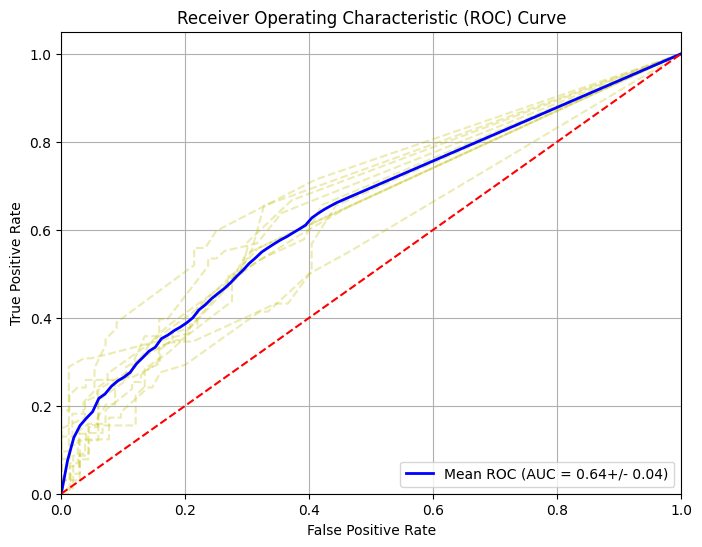

Mean accuracy:  0.6012849287397598 +/- 0.04206324648650838
[[50 19]
 [33 31]]


In [201]:
X = huc8_afff_users_df[['Airports_Count','Military_Bases_Count','Fire_Stations_Count']].values
y = huc8_afff_users_df['violation_status'].values
kf = KFold(n_splits=10, shuffle=True)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()

roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []


# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = LogisticRegression(solver='liblinear')         
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba )
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_list)

plt.figure(figsize=(8, 6))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))
print(conf_matrix)


/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/392025107.py:7: RuntimeWarning:

invalid value encountered in scalar divide



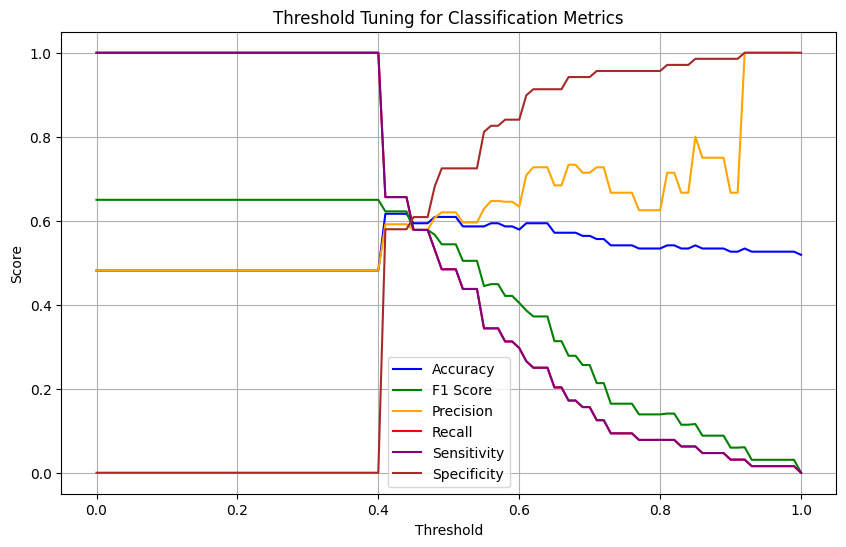

In [202]:
thresholds_for_tuning = np.arange(0.0, 1.01, 0.01)
accuracy_store, f1_score_store, precision_store, recall_store, sensitivity_store, specificity_store = [], [], [], [], [], []
for item in thresholds_for_tuning:
    y_pred_thresholded = (y_pred_proba >= item).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    f1_score = (2 * np.sum(y_test * y_pred_thresholded)) / (np.sum(y_test) + np.sum(y_pred_thresholded))
    precision = np.sum(y_test * y_pred_thresholded) / np.sum(y_pred_thresholded)
    recall = np.sum(y_test * y_pred_thresholded) / np.sum(y_test)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    accuracy_store.append(accuracy)
    f1_score_store.append(f1_score)
    precision_store.append(precision)
    recall_store.append(recall)
    sensitivity_store.append(sensitivity)
    specificity_store.append(specificity)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_for_tuning, accuracy_store, label='Accuracy', color='blue')
plt.plot(thresholds_for_tuning, f1_score_store, label='F1 Score', color='green')
plt.plot(thresholds_for_tuning, precision_store, label='Precision', color='orange')
plt.plot(thresholds_for_tuning, recall_store, label='Recall', color='red')
plt.plot(thresholds_for_tuning, sensitivity_store, label='Sensitivity', color='purple')
plt.plot(thresholds_for_tuning, specificity_store, label='Specificity', color='brown')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Classification Metrics')
plt.legend()
plt.grid()
plt.show()


# Model C- Training a 10-fold cross validated Model on broken down counts of industry

In [203]:
from tqdm import tqdm

# Step 1: Group and count once
counts = (
    joined[joined['naics_group'].isin(NAICS_CODES_OF_INTEREST)]
    .groupby(['HUC8', 'naics_group'])
    .size()
    .reset_index(name='count')
)

# Step 2: Pivot so each naics_group is a column
pivoted = counts.pivot(index='HUC8', columns='naics_group', values='count').fillna(0).astype(int)

# Step 3: Merge with gdf_in_ucmr on HUC8
gdf_in_ucmr_model_C = gdf_in_ucmr.merge(pivoted, how='left', on='HUC8')

# Step 4: Fill missing counts with 0
gdf_in_ucmr_model_C[NAICS_CODES_OF_INTEREST] = gdf_in_ucmr_model_C[NAICS_CODES_OF_INTEREST].fillna(0).astype(int)

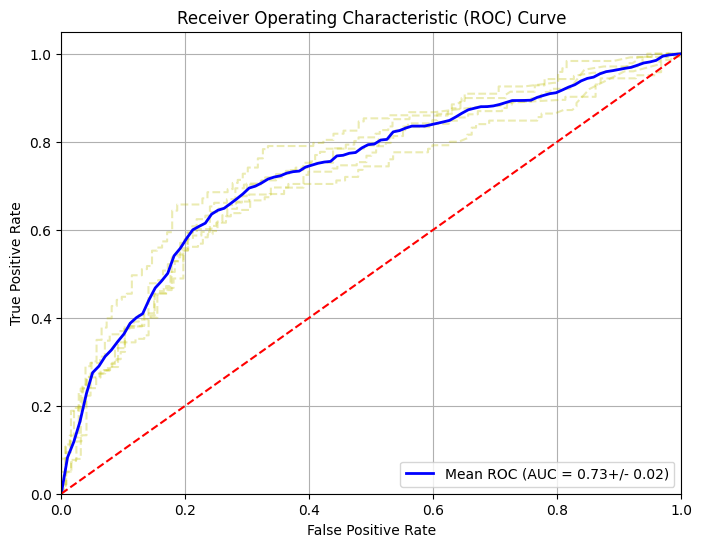

Mean accuracy:  0.6959336543606206 +/- 0.020622426539698424


In [204]:
X = gdf_in_ucmr_model_C.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
y = gdf_in_ucmr_model_C['violation_status'].values
kf = KFold(n_splits=5, shuffle=True)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()

roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []

model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')
# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1, drop_intermediate=False, )
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_list)

plt.figure(figsize=(8, 6))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))


##### Tuning Threshold

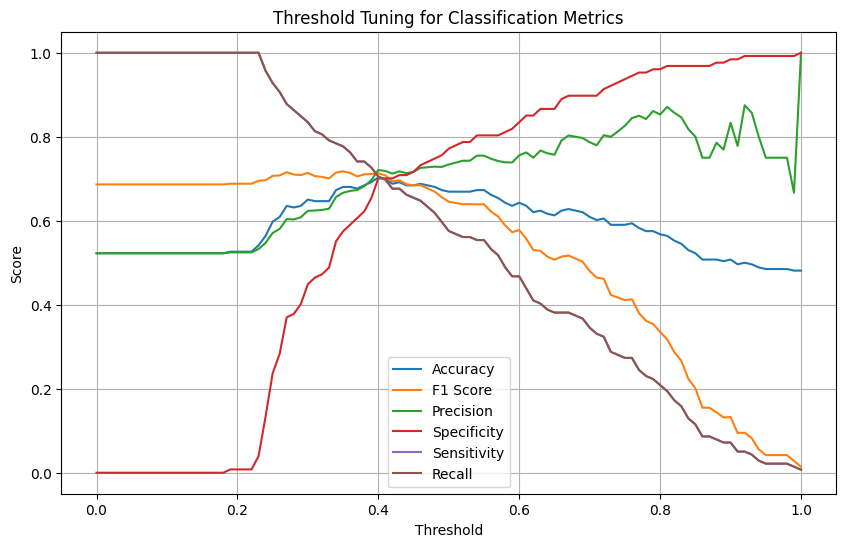

In [205]:
thresholds_for_tuning = np.arange(0.0, 1.01, 0.01)
accuracy_store, f1_score_store, precision_store, recall_store, sensitivity_store, specificity_store = [], [], [], [], [], []
for item in thresholds_for_tuning:
    y_pred_thresholded = (y_pred_proba >= item).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    f1_score = (2 * np.sum(y_test * y_pred_thresholded)) / (np.sum(y_test) + np.sum(y_pred_thresholded))
    precision = np.sum(y_test * y_pred_thresholded) / np.sum(y_pred_thresholded)
    recall = np.sum(y_test * y_pred_thresholded) / np.sum(y_test)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    accuracy_store.append(accuracy)
    f1_score_store.append(f1_score)
    precision_store.append(precision)
    recall_store.append(recall)
    sensitivity_store.append(sensitivity)
    specificity_store.append(specificity)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_for_tuning, accuracy_store, label='Accuracy')
plt.plot(thresholds_for_tuning, f1_score_store, label='F1 Score')
plt.plot(thresholds_for_tuning, precision_store, label='Precision')
plt.plot(thresholds_for_tuning, specificity_store, label='Specificity')
plt.plot(thresholds_for_tuning, sensitivity_store, label='Sensitivity')
plt.plot(thresholds_for_tuning, recall_store, label='Recall')


plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Classification Metrics')
plt.legend()
plt.grid()
plt.show()


# Model D - 10-fold cross validated Random Forest Model of Industry Data + AFFF Foam users

In [206]:
gdf_in_ucmr_model_D = gdf_in_ucmr_model_C.copy()
for index, row in gdf_in_ucmr_model_D.iterrows():
    huc8 = row['HUC8']
    airport_count = huc8_afff_users_df[huc8_afff_users_df.HUC8 == huc8]['Airports_Count'].values[0]
    military_base_count = huc8_afff_users_df[huc8_afff_users_df.HUC8 == huc8]['Military_Bases_Count'].values[0]
    fire_station_count = huc8_afff_users_df[huc8_afff_users_df.HUC8 == huc8]['Fire_Stations_Count'].values[0]
    area = row['geometry'].area
    airport_density = airport_count / area if area != 0 else 0
    military_base_density = military_base_count / area if area != 0 else 0
    fire_station_density = fire_station_count / area if area != 0 else 0
    gdf_in_ucmr_model_D.at[index, 'Airport_Density'] = airport_density
    gdf_in_ucmr_model_D.at[index, 'Military_Base_Density'] = military_base_density
    gdf_in_ucmr_model_D.at[index, 'Fire_Station_Density'] = fire_station_density
print("\nShape of gdf_in_ucmr_model_D after adding AFFF users density:", gdf_in_ucmr_model_D.shape)
print("Column Names in gdf_in_ucmr_model_D:", gdf_in_ucmr_model_D.columns)



Shape of gdf_in_ucmr_model_D after adding AFFF users density: (1332, 34)
Column Names in gdf_in_ucmr_model_D: Index([                 'HUC8',              'geometry',
                        'NAME',        'Industry_Count',
                     'density',      'violation_status',
                        313210,                  322121,
                        323111,                  324110,
                        324191,                  325199,
                        325211,                  325510,
                        325611,                  325612,
                        325998,                  326112,
                        326113,                  332812,
                        332813,                  332999,
                        334413,                  334419,
                        335999,                  424690,
                        562112,                  562211,
                        562212,                  562213,
                        562219,   

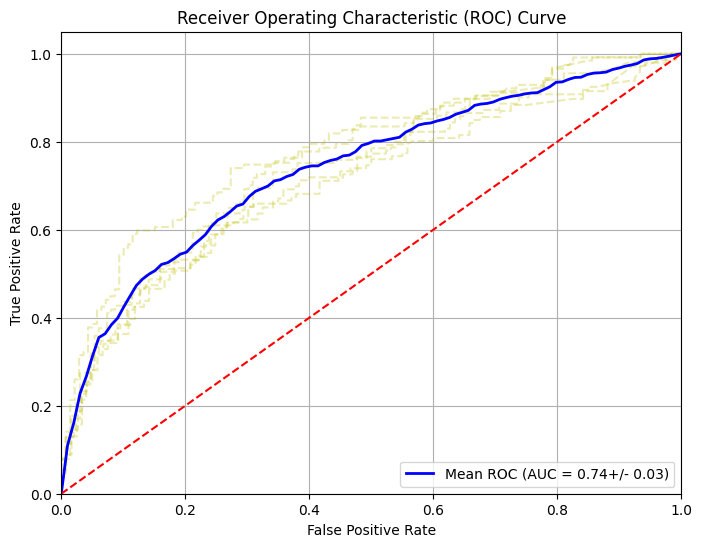

Mean accuracy:  0.6839373715186844 +/- 0.0226715779578572


In [207]:
X = gdf_in_ucmr_model_D.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
y = gdf_in_ucmr_model_D['violation_status'].values
kf = KFold(n_splits=5, shuffle=True)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()

roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []

model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')
# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1, drop_intermediate=False, )
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_list)

plt.figure(figsize=(8, 6))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))


##### Tuning Threshold for Model D

/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/3165296269.py:7: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/3165296269.py:7: RuntimeWarning:

invalid value encountered in scalar divide



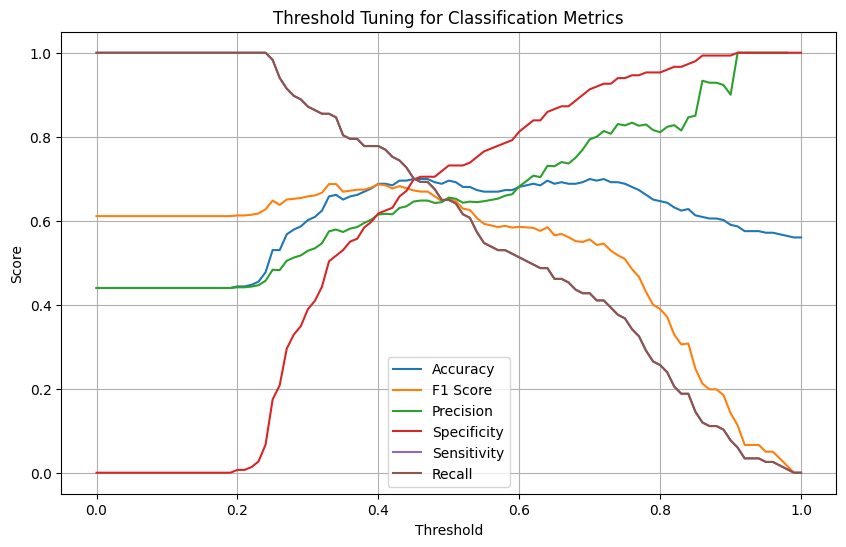

In [208]:
thresholds_for_tuning = np.arange(0.0, 1.01, 0.01)
accuracy_store, f1_score_store, precision_store, recall_store, sensitivity_store, specificity_store = [], [], [], [], [], []
for item in thresholds_for_tuning:
    y_pred_thresholded = (y_pred_proba >= item).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    f1_score = (2 * np.sum(y_test * y_pred_thresholded)) / (np.sum(y_test) + np.sum(y_pred_thresholded))
    precision = np.sum(y_test * y_pred_thresholded) / np.sum(y_pred_thresholded)
    recall = np.sum(y_test * y_pred_thresholded) / np.sum(y_test)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    accuracy_store.append(accuracy)
    f1_score_store.append(f1_score)
    precision_store.append(precision)
    recall_store.append(recall)
    sensitivity_store.append(sensitivity)
    specificity_store.append(specificity)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_for_tuning, accuracy_store, label='Accuracy')
plt.plot(thresholds_for_tuning, f1_score_store, label='F1 Score')
plt.plot(thresholds_for_tuning, precision_store, label='Precision')
plt.plot(thresholds_for_tuning, specificity_store, label='Specificity')
plt.plot(thresholds_for_tuning, sensitivity_store, label='Sensitivity')
plt.plot(thresholds_for_tuning, recall_store, label='Recall')


plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Classification Metrics')
plt.legend()
plt.grid()
plt.show()


# Model E- Training 10-fold cross validated Random Forest Model on Industry + AFFF + Sociodemographic Data

##### Loading the socio demographic data

In [209]:
from shapely import wkt
zcta_data_with_geolocations = pd.read_csv(f"{cwd}/source_data_files/generated-data-files/zcta_data_with_geolocations.csv")
zcta_data_with_geolocations = zcta_data_with_geolocations.drop(columns=["latitude","longitude"])
zcta_data_with_geolocations['geometry'] = zcta_data_with_geolocations['geometry'].apply(wkt.loads)

In [210]:
# Ensure both GeoDataFrames are in the same CRS
zcta_data_with_geolocations = gpd.GeoDataFrame(zcta_data_with_geolocations, geometry='geometry', crs="EPSG:4326")
# zcta_data_with_geolocations = zcta_data_with_geolocations.to_crs(gdf_in_ucmr.crs)
# Spatial join: assign HUC8 from polygons to points
zcta_with_huc8 = gpd.sjoin(
    zcta_data_with_geolocations,
    gdf_in_ucmr[['HUC8', 'geometry']],
    how='left',
    predicate='within'  # or 'contains', but 'within' is better when matching point-in-polygon
)
# Drop the spatial index column if you don't need it
zcta_with_huc8 = zcta_with_huc8.drop(columns='index_right')

print("Shape of zcta_with_huc8:", zcta_with_huc8.shape)
print("Unique HUC8s in zcta_with_huc8:", zcta_with_huc8['HUC8'].nunique())
print("Column Names in zcta_with_huc8:", zcta_with_huc8.columns)

Shape of zcta_with_huc8: (32428, 5)
Unique HUC8s in zcta_with_huc8: 1330
Column Names in zcta_with_huc8: Index(['index', 'LOCATION', 'RPL_THEMES', 'geometry', 'HUC8'], dtype='object')


In [211]:
rpl_themes_by_huc8 = zcta_with_huc8[['HUC8','RPL_THEMES']].groupby('HUC8').mean().reset_index()
rpl_themes_by_huc8["HUC8"] = rpl_themes_by_huc8["HUC8"].astype(str)
rpl_themes_by_huc8.index = rpl_themes_by_huc8.index.astype(str)

In [212]:
gdf_in_ucmr_model_E = gdf_in_ucmr_model_D.copy()
gdf_in_ucmr_model_E = gpd.GeoDataFrame(gdf_in_ucmr_model_E, geometry='geometry', crs="EPSG:4326")
for index, row in gdf_in_ucmr_model_E.iterrows():
    huc8 = row['HUC8']
    if huc8 in rpl_themes_by_huc8['HUC8'].values:
        rpl_themes = rpl_themes_by_huc8[rpl_themes_by_huc8['HUC8'] == huc8]['RPL_THEMES'].values[0]
        gdf_in_ucmr_model_E.at[index, 'RPL_THEMES'] = rpl_themes
    else:
        gdf_in_ucmr_model_E.at[index, 'RPL_THEMES'] = np.nan
gdf_in_ucmr_model_E.rename(columns={'RPL_THEMES': 'Mean_SVI'}, inplace=True)
print("\nShape of gdf_in_ucmr_model_E after adding RPL_THEMES:", gdf_in_ucmr_model_E.shape)
print("Column Names in gdf_in_ucmr_model_E:", gdf_in_ucmr_model_E.columns)




Shape of gdf_in_ucmr_model_E after adding RPL_THEMES: (1332, 35)
Column Names in gdf_in_ucmr_model_E: Index([                 'HUC8',              'geometry',
                        'NAME',        'Industry_Count',
                     'density',      'violation_status',
                        313210,                  322121,
                        323111,                  324110,
                        324191,                  325199,
                        325211,                  325510,
                        325611,                  325612,
                        325998,                  326112,
                        326113,                  332812,
                        332813,                  332999,
                        334413,                  334419,
                        335999,                  424690,
                        562112,                  562211,
                        562212,                  562213,
                        562219,       'Air

In [213]:
# Data Source: https://nanda.isr.umich.edu/project/socioeconomic-status-and-demographic-characteristics/
nanda_data_filename = f"{cwd}/source_data_files/generated-data-files/nanda_data_with_geolocations.csv"
nanda_data = pd.read_csv(nanda_data_filename)
nanda_data['geometry'] = nanda_data['geometry'].apply(wkt.loads)
nanda_data = gpd.GeoDataFrame(nanda_data, geometry='geometry', crs="EPSG:4326")
gdf_in_ucmr_model_E = gdf_in_ucmr_model_E.to_crs(epsg=4326)  # Ensure both GeoDataFrames are in the same CRS

# Spatial join nanda_data and gdf_in_ucmr_model_E
nanda_with_huc8 = gpd.sjoin(
    gdf_in_ucmr_model_E[['HUC8', 'geometry']],
    nanda_data,
    how='left',
    predicate='contains',  # or 'contains', but 'within' is better when matching point-in-polygon
    
)
nanda_with_huc8.drop(columns=['index_right','geometry','ZCTA'], inplace=True)
for index, row in nanda_with_huc8.iterrows():
    try:
        nanda_with_huc8.at[index,"AFFLUENCE"] = float(row["AFFLUENCE"])
        nanda_with_huc8.at[index,"DISADVANTAGE"] = float(row["DISADVANTAGE"])
    except ValueError:
        nanda_with_huc8.at[index,"AFFLUENCE"] = np.nan
        nanda_with_huc8.at[index,"DISADVANTAGE"] = np.nan
nanda_with_huc8["AFFLUENCE"] = nanda_with_huc8.AFFLUENCE.astype(float)
nanda_with_huc8["DISADVANTAGE"] = nanda_with_huc8.DISADVANTAGE.astype(float)
nanda_pop_data = nanda_with_huc8[["HUC8","TOTPOP"]].groupby("HUC8").sum().reset_index()
nanda_demograph_data = nanda_with_huc8[["HUC8","AFFLUENCE", "DISADVANTAGE"]].groupby("HUC8").mean().reset_index()
gdf_in_ucmr_model_E = gdf_in_ucmr_model_E.merge(nanda_pop_data, on="HUC8", how="left", suffixes=('', '_pop'))
gdf_in_ucmr_model_E = gdf_in_ucmr_model_E.merge(nanda_demograph_data, on="HUC8", how="left", suffixes=('', '_demograph'))

#### Training the model

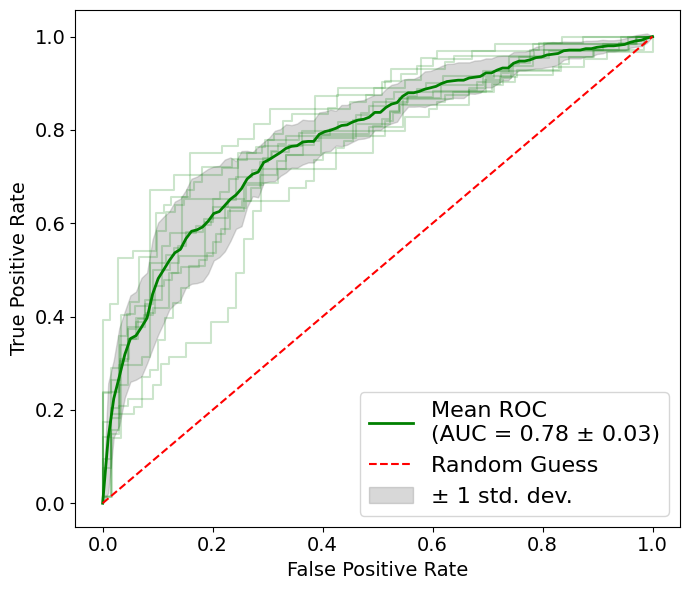

Mean accuracy:  0.7192346537986758 +/- 0.027996097521740877


In [225]:
# gdf_in_ucmr_model_E.dropna(inplace=True)
X = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
# X= gdf_in_ucmr_model_E[['TOTPOP', 'AFFLUENCE', 'DISADVANTAGE']].values
y = gdf_in_ucmr_model_E['violation_status'].values
kf = KFold(n_splits=10, shuffle=True, random_state=101)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X_scaled = StandardScaler().fit_transform(X)  # Important to scale!


roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []
feature_ranks = []
feature_names = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).columns
model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=101)
# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # # Optional: PCA for dimensionality reduction
    # pca = PCA(n_components=X.shape[1])  # Adjust n_components as needed
    # X_train_scaled = pca.fit_transform(X_train_scaled)
    # X_test_scaled = pca.transform(X_test_scaled)

    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1, drop_intermediate=False, )
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    # importances = model.feature_importances_
    # ranks = pd.Series(importances, index=feature_names).rank(ascending=False)
    # feature_ranks.append(ranks)

tpr_interp = []
auc_list = []

for fpr, tpr in zip(fpr_list, tpr_list):
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tpr_interp.append(interp_tpr)
        auc_list.append(auc(fpr, tpr))

# Convert to array for stats
tpr_interp = np.array(tpr_interp)
mean_tpr = tpr_interp.mean(axis=0)
std_tpr = tpr_interp.std(axis=0)
mean_auc = np.mean(auc_list)
std_auc = np.std(auc_list)

model_E_results = [tpr_list, fpr_list, mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc, accuracy_list]

# Plot
plt.figure(figsize=(7, 6))

# Individual ROC curves
for i in range(len(tpr_list)):
    plt.plot(fpr_list[i], tpr_list[i],
            color='green', alpha=0.2)

# Mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='green', label=f'Mean ROC \n(AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2)

# Random classifier line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

# Shaded std dev area
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='grey', alpha=0.3, label='± 1 std. dev.')

# Labels and legend
plt.xlabel("False Positive Rate", fontsize = 14)
plt.ylabel("True Positive Rate", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title(f"ROC Curve (5-Fold Cross-Validation)_{random_state_val}")
plt.legend(loc="lower right")
plt.legend(fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))

# # Convert feature names from NAICS code to NAICS name:
# feature_names = [str(name) for name in feature_names]
# for naics_code in NAICS_CODES_OF_INTEREST:
#     if naics_code in naics_names_modeled['NAICS_Code'].values:
#         feature_names = feature_names.str.replace(naics_code, naics_names_modeled[naics_names_modeled['NAICS_Code'] == naics_code]['NAICS_Name'].values[0], regex=False)

# # # Convert to DataFrame
# # rank_df = pd.DataFrame(feature_ranks)

# # # Calculate standard deviation of ranks across folds
# # rank_stability = rank_df.std().sort_values()

# # # Output
# # print("Feature Rank Stability (lower = more stable across folds):")
# # print(rank_stability)

# # # Optional: visualize
# # import matplotlib.pyplot as plt
# # rank_stability.plot.barh(figsize=(8, 10), title='Feature Rank Stability (Std Dev of Ranks)')
# # plt.xlabel("Rank Std Dev (Lower is More Stable)")
# # plt.tight_layout()
# # plt.show()

##### Tuning Threshold

/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/46806820.py:7: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/46806820.py:7: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/wn/821x078d3pj0t3bvh3rd95l80000gn/T/ipykernel_7413/46806820.py:7: RuntimeWarning:

invalid value encountered in scalar divide



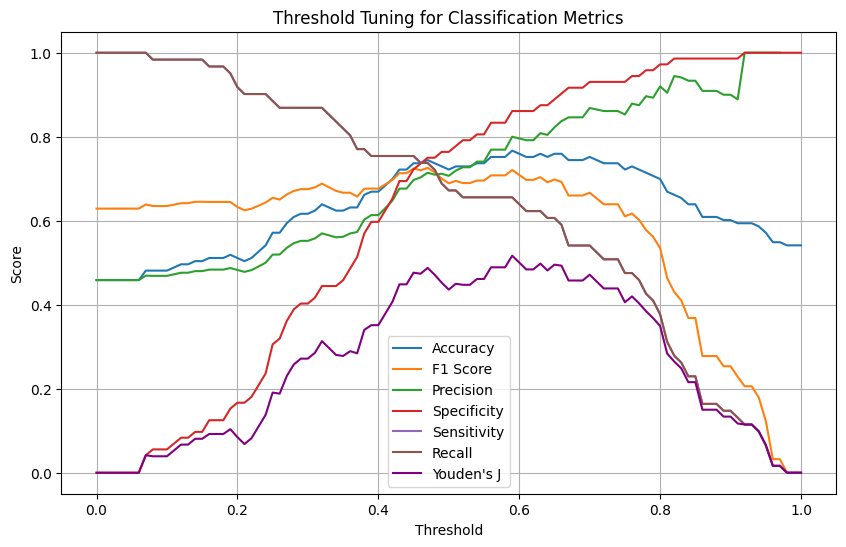

In [215]:
thresholds_for_tuning = np.arange(0.0, 1.01, 0.01)
accuracy_store, f1_score_store, precision_store, recall_store, sensitivity_store, specificity_store, youdens_j_store = [], [], [], [], [], [], []
for item in thresholds_for_tuning:
    y_pred_thresholded = (y_pred_proba >= item).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    f1_score = (2 * np.sum(y_test * y_pred_thresholded)) / (np.sum(y_test) + np.sum(y_pred_thresholded))
    precision = np.sum(y_test * y_pred_thresholded) / np.sum(y_pred_thresholded)
    recall = np.sum(y_test * y_pred_thresholded) / np.sum(y_test)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    youdens_j = sensitivity + specificity - 1
    youdens_j_store.append(youdens_j)
    accuracy_store.append(accuracy)
    f1_score_store.append(f1_score)
    precision_store.append(precision)
    recall_store.append(recall)
    sensitivity_store.append(sensitivity)
    specificity_store.append(specificity)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_for_tuning, accuracy_store, label='Accuracy')
plt.plot(thresholds_for_tuning, f1_score_store, label='F1 Score')
plt.plot(thresholds_for_tuning, precision_store, label='Precision')
plt.plot(thresholds_for_tuning, specificity_store, label='Specificity')
plt.plot(thresholds_for_tuning, sensitivity_store, label='Sensitivity')
plt.plot(thresholds_for_tuning, recall_store, label='Recall')
plt.plot(thresholds_for_tuning, youdens_j_store, label='Youden\'s J', color='purple')


plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Classification Metrics')
plt.legend()
plt.grid()
plt.show()


In [216]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_store, precision_store, recall_store, f1_store, youdens_j_store = [], [], [], [], []
threshold_range = np.arange(0,1.01, 0.02)
for threshold in threshold_range:
    y_pred_thresholded = (y_pred_proba >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresholded)
    precision = precision_score(y_test, y_pred_thresholded)
    recall = recall_score(y_test, y_pred_thresholded)
    f1 = f1_score(y_test, y_pred_thresholded)
    sensitivity = recall
    specificity = np.sum((1 - y_test) * (1 - y_pred_thresholded)) / np.sum(1 - y_test)
    youdens_j = sensitivity + specificity - 1
    accuracy_store.append(accuracy)
    precision_store.append(precision)
    recall_store.append(recall)
    f1_store.append(f1)
    youdens_j_store.append(youdens_j)
# Find the threshold with the maximum Youden's J statistic
    

max_youden_index = np.argmax(youdens_j_store)
optimal_threshold = threshold_range[max_youden_index]
optimal_accuracy = accuracy_store[max_youden_index]
optimal_precision = precision_store[max_youden_index]
optimal_recall = recall_store[max_youden_index]
optimal_f1 = f1_store[max_youden_index]
optimal_youden_index = youdens_j_store[max_youden_index]
store_to_send = [optimal_threshold, optimal_accuracy, optimal_precision, optimal_recall, optimal_f1, optimal_youden_index]
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Optimal Accuracy: {optimal_accuracy:.2f}")
print(f"Optimal Precision: {optimal_precision:.2f}")
print(f"Optimal Recall: {optimal_recall:.2f}")
print(f"Optimal F1 Score: {optimal_f1:.2f}")
print(f"Optimal Youden's J: {optimal_youden_index:.2f}")

Optimal Threshold: 0.60
Optimal Accuracy: 0.76
Optimal Precision: 0.80
Optimal Recall: 0.64
Optimal F1 Score: 0.71
Optimal Youden's J: 0.50


/opt/anaconda3/envs/pfas2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/pfas2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [217]:
models_folder = "/Users/pg13/Documents/Personal-Projects/PFAS-Project/source_data_files/generated-data-files/models-finalized/"
contaminant = contaminants_of_interest[0]
with open(f"{models_folder}/all-contaminants.pkl", "wb") as f:
    pickle.dump([model, scaler, optimal_threshold], f)

In [218]:
gdf_for_correlation = gdf_in_ucmr_model_E.copy()
for index, row in gdf_for_correlation.iterrows():
    area = row['geometry'].area
    pop_density = row['TOTPOP'] / area if area != 0 else 0
    gdf_for_correlation.at[index, 'Population_Density'] = pop_density

In [219]:
#calculate correlation between column TOTPOP and Population_Density
correlation = gdf_for_correlation['TOTPOP'].corr(gdf_for_correlation['Population_Density'])
# calculate spearman correlation
spearman_correlation = gdf_for_correlation['TOTPOP'].corr(gdf_for_correlation['Population_Density'], method='spearman')
print(f"Spearman Correlation between TOTPOP and Population_Density: {spearman_correlation:.2f}")
print(f"Correlation between TOTPOP and Population_Density: {correlation:.2f}")

Spearman Correlation between TOTPOP and Population_Density: 0.92
Correlation between TOTPOP and Population_Density: 0.74


# Feature Importance on Model E

In [220]:
naics_categories = pd.read_csv("/Users/pg13/Documents/Personal-Projects/PFAS-Project/source_data_files/NAICS_files/NAICS_Product_Category_Table.csv")
# naics_categories

In [221]:
naics_names = pd.read_excel("/Users/pg13/Documents/Personal-Projects/PFAS-Project/source_data_files/2017-NAICS-2-3-4-5-6-Digit-Codes-Listed-Numerically.xlsx", sheet_name="6 Digit NAICS", header=0)
naics_names = naics_names[['Six Digit NAICS Codes', '2017 NAICS Title (USA)']].dropna().reset_index(drop=True)
naics_names.columns = ['NAICS_Code', 'NAICS_Name']
naics_names_filtered = naics_names[naics_names['NAICS_Code'].isin(NAICS_CODES_OF_INTEREST)].reset_index(drop=True)

# naics_names

In [222]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 25))
# Ensure X_train has feature names
feature_columns = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).columns
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_columns)
naics_names_modeled = naics_names[naics_names['NAICS_Code'].isin(NAICS_CODES_OF_INTEREST)].reset_index(drop=True)
for naics_code in NAICS_CODES_OF_INTEREST:
    if naics_code in naics_names_modeled['NAICS_Code'].values:
        X_train_df.rename(columns={naics_code: naics_names_modeled[naics_names_modeled['NAICS_Code']==naics_code]['NAICS_Name'].values[0]}, inplace=True)
    


# for i in range(24):
#     X_train_df.rename(columns={i: f"NAICS {NAICS_CODES_OF_INTEREST[i]}"}, inplace=True)
# X_train_df.rename(columns={'fire_density': 'Fire Fighting Training Density', 'military_density': 'Military Installation Density', 'airport_density': 'Airport Density', 'TOTPOP': 'Total Population'}, inplace=True)
# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_df)

# Check shape of shap_values
print(type(shap_values), len(shap_values), shap_values[0].shape)

import shap
import matplotlib.pyplot as plt

# Helper function to truncate strings
def truncate_label(label, max_chars=40):
    return label if len(str(label)) <= max_chars else label[:max_chars - 3] + "..."

# Truncate feature names
short_names = [truncate_label(col, max_chars=60) for col in X_train_df.columns]

# Create a renamed copy of the DataFrame
X_trunc = X_train_df.copy()
X_trunc.columns = short_names

# Set larger figure to accommodate labels
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values[:, :, 1], X_trunc, show=False)
plt.tight_layout()
plt.show()

ValueError: Shape of passed values is (1199, 3), indices imply (1199, 32)

<Figure size 1000x2500 with 0 Axes>

In [226]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 25))
# Ensure X_train has feature names
feature_columns = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).columns
X_train_df = pd.DataFrame(X_train_scaled, columns=['TOTPOP'])
naics_names_modeled = naics_names[naics_names['NAICS_Code'].isin(NAICS_CODES_OF_INTEREST)].reset_index(drop=True)
# for naics_code in NAICS_CODES_OF_INTEREST:
#     if naics_code in naics_names_modeled['NAICS_Code'].values:
#         X_train_df.rename(columns={naics_code: naics_names_modeled[naics_names_modeled['NAICS_Code']==naics_code]['NAICS_Name'].values[0]}, inplace=True)
    


# for i in range(24):
#     X_train_df.rename(columns={i: f"NAICS {NAICS_CODES_OF_INTEREST[i]}"}, inplace=True)
# X_train_df.rename(columns={'fire_density': 'Fire Fighting Training Density', 'military_density': 'Military Installation Density', 'airport_density': 'Airport Density', 'TOTPOP': 'Total Population'}, inplace=True)
# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_df)

# Check shape of shap_values
print(type(shap_values), len(shap_values), shap_values[0].shape)

import shap
import matplotlib.pyplot as plt

# Helper function to truncate strings
def truncate_label(label, max_chars=40):
    return label if len(str(label)) <= max_chars else label[:max_chars - 3] + "..."

# Truncate feature names
short_names = [truncate_label(col, max_chars=60) for col in X_train_df.columns]

# Create a renamed copy of the DataFrame
X_trunc = X_train_df.copy()
X_trunc.columns = short_names

# Set larger figure to accommodate labels
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values[:, :, 1], X_trunc, show=False)
plt.tight_layout()
plt.show()

ValueError: Shape of passed values is (1199, 32), indices imply (1199, 1)

<Figure size 1000x2500 with 0 Axes>

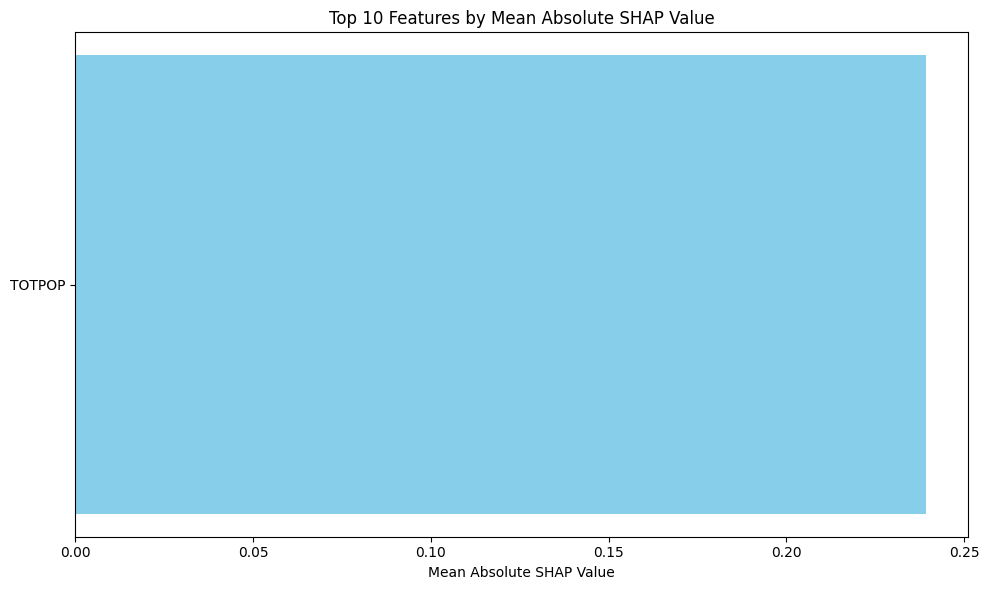

In [ ]:
# get the top 10 features based on mean absolute SHAP values
mean_abs_shap_values = np.mean(np.abs(shap_values[:, :, 1]), axis=0)
top_10_indices = np.argsort(mean_abs_shap_values)[:10][::-1]
top_10_features = X_train_df.columns[top_10_indices]
# include TOTPOP
top_10_features = np.append(top_10_features, 'TOTPOP')
top_10_shap_values = mean_abs_shap_values[top_10_indices]
#include totpop
top_10_shap_values = np.append(top_10_shap_values, np.mean(np.abs(shap_values[:, :, 1][:, -1])))
# Create a DataFrame for the top 10 features
top_10_df = pd.DataFrame({
    'Feature': top_10_features,
    'Mean Absolute SHAP Value': top_10_shap_values
})
# Sort the DataFrame by Mean Absolute SHAP Value
top_10_df = top_10_df.sort_values(by='Mean Absolute SHAP Value', ascending=False)
# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_10_df['Feature'], top_10_df['Mean Absolute SHAP Value'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 10 Features by Mean Absolute SHAP Value')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest value on top
plt.tight_layout()
plt.show()


In [ ]:
for naics_code in NAICS_CODES_OF_INTEREST:
    if naics_code in naics_names_modeled['NAICS_Code'].values:
        X_train_df.rename(columns={naics_code: naics_names_modeled[naics_names_modeled['NAICS_Code']==naics_code]['NAICS_Name'].values[0]}, inplace=True)

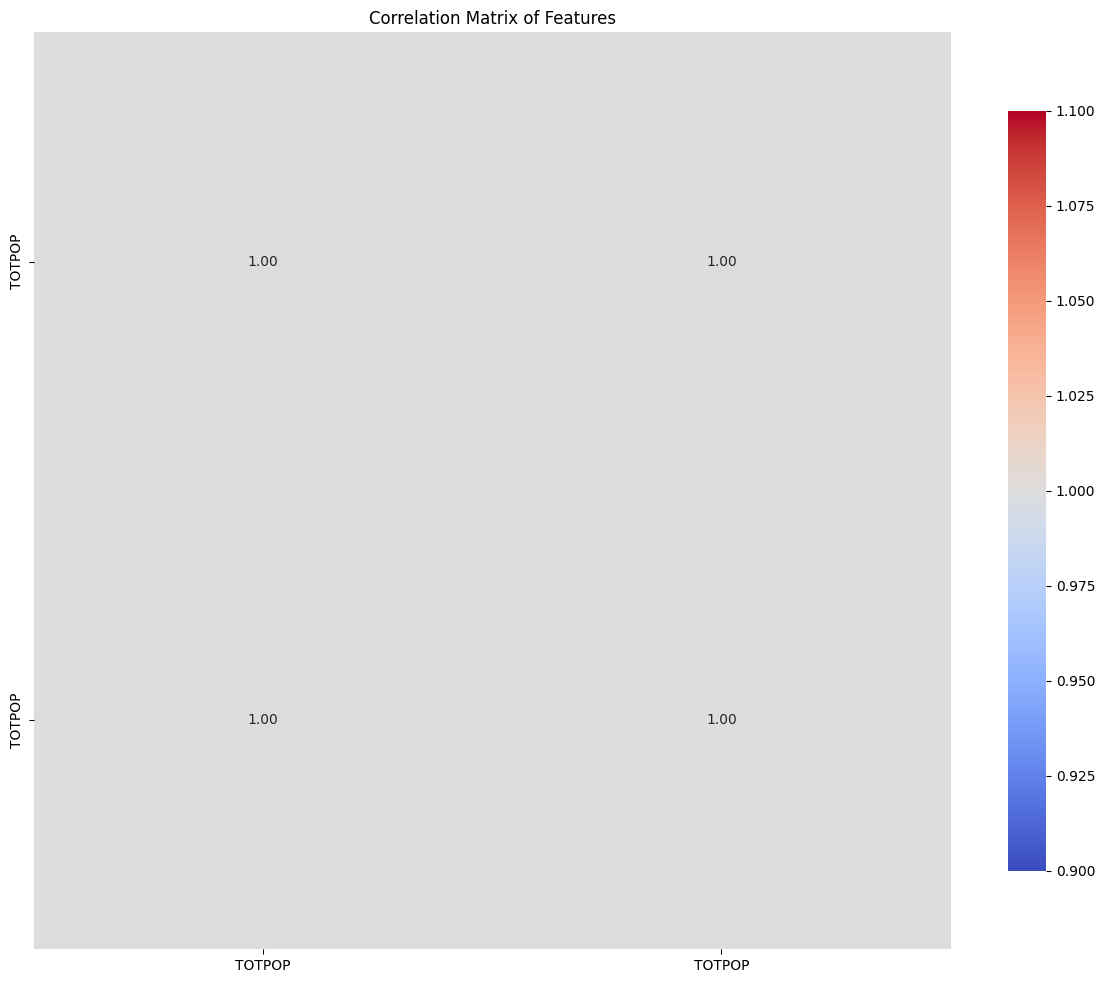

In [ ]:
# make and plot a correlation matrix for X_train_df , and show 

import seaborn as sns
corr_matrix = X_train_df[top_10_df['Feature'].values].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

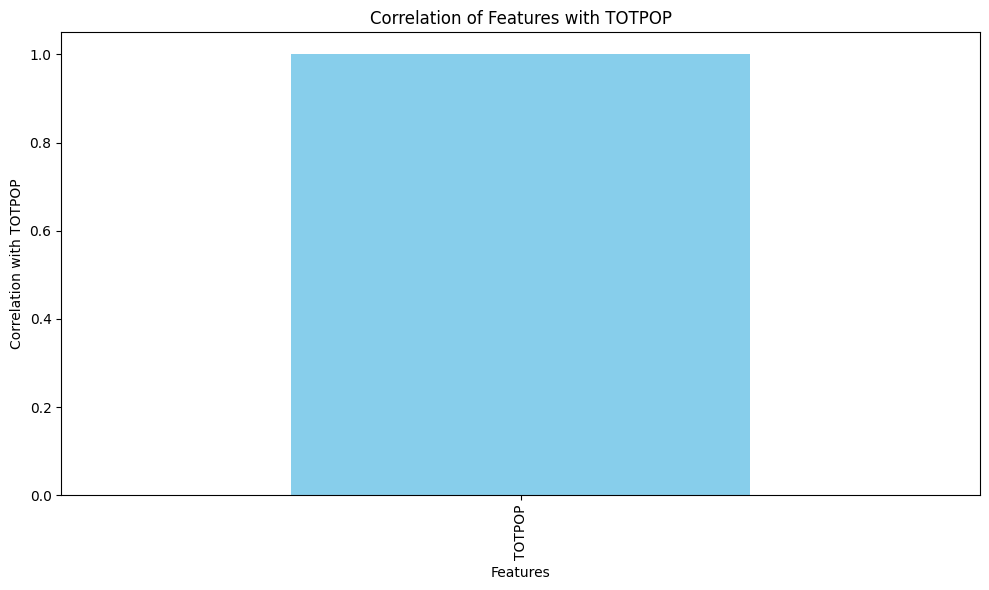

In [ ]:
# Plot a bar plot of the correlation of all features w.r.t. TOTPOP
totpop_correlation = X_train_df.corr()['TOTPOP'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
totpop_correlation.plot(kind='bar', color='skyblue')
plt.xlabel('Features')
plt.ylabel('Correlation with TOTPOP')
plt.title('Correlation of Features with TOTPOP')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Make a list of the feature groups that have correlation > 0.5
corr_matrix = corr_matrix.abs()
high_corr_features = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.5:
            feature_pair = (corr_matrix.columns[i], corr_matrix.columns[j])
            high_corr_features.append(feature_pair)
print("Highly correlated feature pairs (correlation > 0.5):")
for feature1, feature2 in high_corr_features:
    print(f"{feature1} and {feature2} with correlation {corr_matrix.loc[feature1, feature2]:.2f}")


Highly correlated feature pairs (correlation > 0.5):
Unlaminated Plastics Film and Sheet (except Packaging) Manufacturing  and Soap and Other Detergent Manufacturing  with correlation 0.75
All Other Miscellaneous Electrical Equipment and Component Manufacturing  and Soap and Other Detergent Manufacturing  with correlation 0.63
All Other Miscellaneous Electrical Equipment and Component Manufacturing  and Semiconductor and Related Device Manufacturing  with correlation 0.58
All Other Miscellaneous Electrical Equipment and Component Manufacturing  and Unlaminated Plastics Film and Sheet (except Packaging) Manufacturing  with correlation 0.66
Polish and Other Sanitation Good Manufacturing  and Soap and Other Detergent Manufacturing  with correlation 0.91
Polish and Other Sanitation Good Manufacturing  and Unlaminated Plastics Film and Sheet (except Packaging) Manufacturing  with correlation 0.74
Polish and Other Sanitation Good Manufacturing  and All Other Miscellaneous Electrical Equipmen

Text(0.5, 1.0, 'Mean Impact of Features on Model Output')

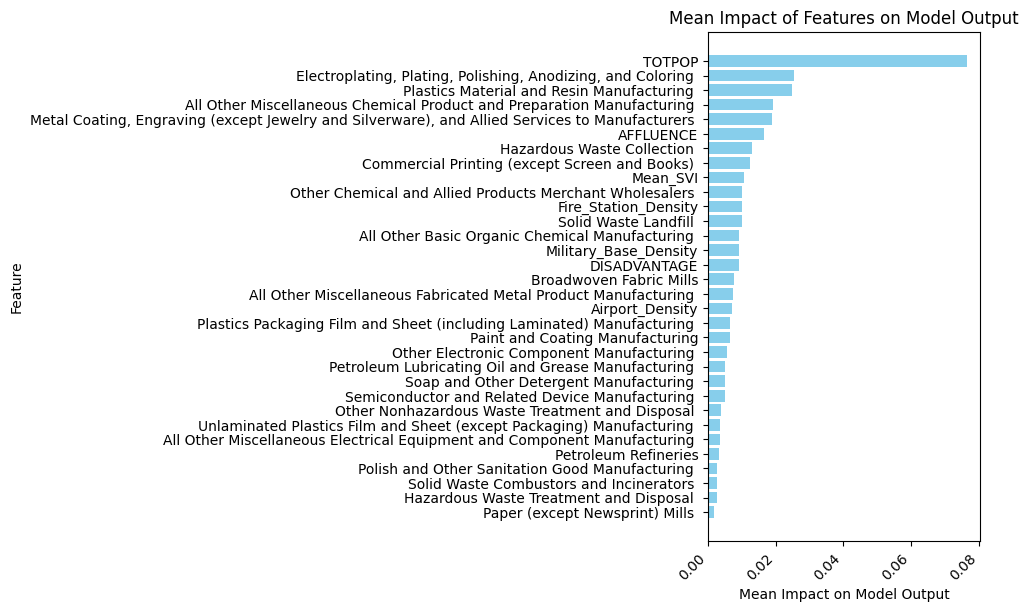

In [ ]:
impact_sum_of_training_data = np.zeros(shap_values.shape[1])
for i in range(len(shap_values)):
    impact_of_this_data_point = np.absolute(shap_values[i, :, 1])
    impact_sum_of_training_data += impact_of_this_data_point
impact_mean_of_training_data = impact_sum_of_training_data / len(shap_values)
impact_df = pd.DataFrame({"Feature": X_train_df.columns, "Mean Impact": impact_mean_of_training_data})
impact_df = impact_df.sort_values(by="Mean Impact", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(impact_df['Feature'], impact_df['Mean Impact'], color='skyblue')
plt.xlabel('Mean Impact on Model Output')
plt.ylabel('Feature')
# plt.xscale('log')  # Use logarithmic scale for better visibility
#break the x-axis to avoid clutter
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.title('Mean Impact of Features on Model Output')

<class 'numpy.ndarray'> 1199 (32, 2)


<Figure size 1000x2500 with 0 Axes>

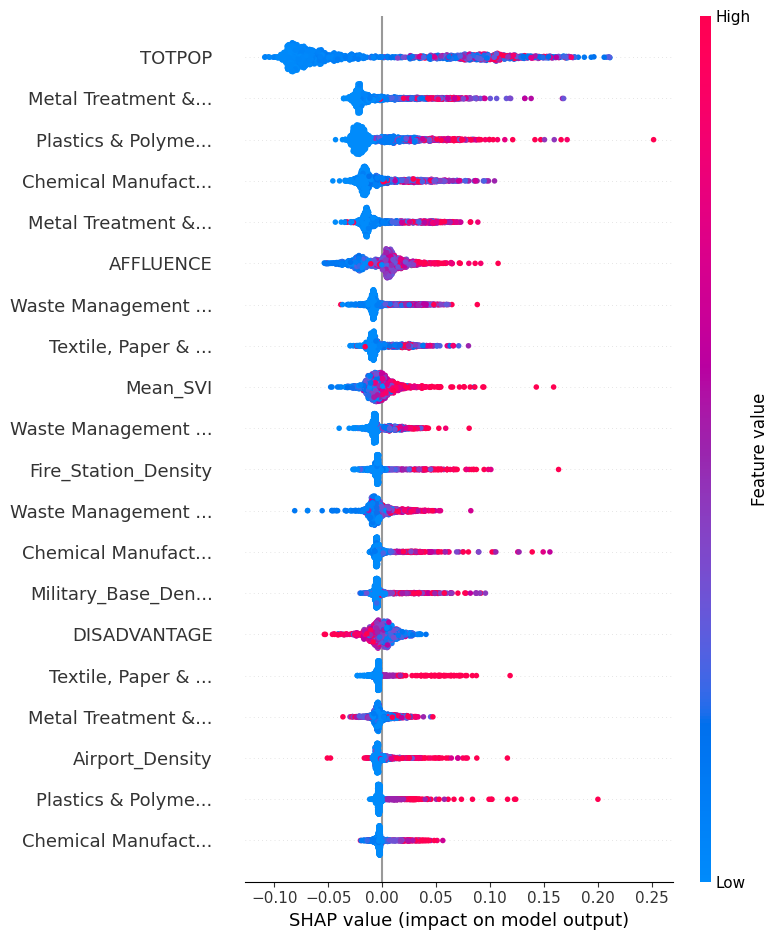

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 25))
# Ensure X_train has feature names
feature_columns = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).columns
X_train_df2 = pd.DataFrame(X_train_scaled, columns=feature_columns)
naics_names_modeled = naics_names[naics_names['NAICS_Code'].isin(NAICS_CODES_OF_INTEREST)].reset_index(drop=True)
for naics_code in NAICS_CODES_OF_INTEREST:
    X_train_df2.rename(columns={naics_code: naics_categories[naics_categories['NAICS_Code']==naics_code]['Product_Category'].values[0]}, inplace=True)


# for i in range(24):
#     X_train_df2.rename(columns={i: f"NAICS {NAICS_CODES_OF_INTEREST[i]}"}, inplace=True)
# X_train_df2.rename(columns={'fire_density': 'Fire Fighting Training Density', 'military_density': 'Military Installation Density', 'airport_density': 'Airport Density', 'TOTPOP': 'Total Population'}, inplace=True)
# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_df2)

# Check shape of shap_values
print(type(shap_values), len(shap_values), shap_values[0].shape)

import shap
import matplotlib.pyplot as plt

# Helper function to truncate strings
def truncate_label(label, max_chars=40):
    return label if len(label) <= max_chars else label[:max_chars - 3] + "..."

# Truncate feature names
short_names = [truncate_label(col, max_chars=20) for col in X_train_df2.columns]

# Create a renamed copy of the DataFrame
X_trunc = X_train_df2.copy()
X_trunc.columns = short_names

# Set larger figure to accommodate labels
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values[:, :, 1], X_trunc, show=False)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Mean Impact of Features on Model Output')

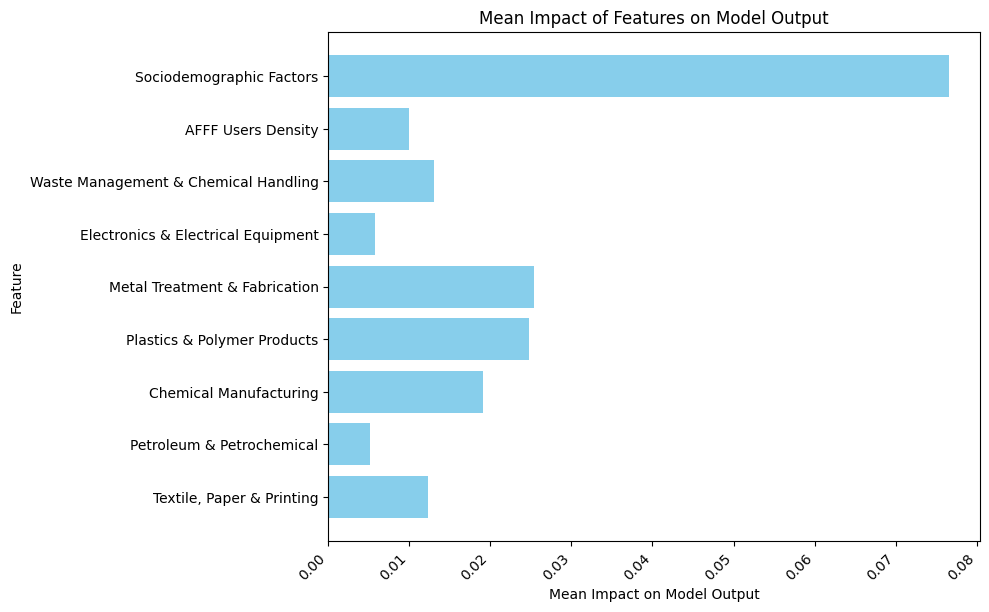

In [ ]:
impact_sum_of_training_data = np.zeros(shap_values.shape[1])
for i in range(len(shap_values)):
    impact_of_this_data_point = np.absolute(shap_values[i, :, 1])
    impact_sum_of_training_data += impact_of_this_data_point
impact_mean_of_training_data = impact_sum_of_training_data / len(shap_values)
impact_df = pd.DataFrame({"Feature": X_train_df.columns, "Mean Impact": impact_mean_of_training_data})
for index, row in impact_df.iterrows():
    feature_name = row['Feature']
    # naics_name = naics_names_filtered['NAICS_Name']
    naics_code = naics_names_filtered[naics_names_filtered['NAICS_Name'] == feature_name]['NAICS_Code'].values[0] if feature_name in naics_names_filtered['NAICS_Name'].values else None
    if naics_code:
        impact_df.at[index, 'Product_category'] = naics_categories[naics_categories['NAICS_Code'] == naics_code]['Product_Category'].values[0]
    if feature_name in ['Airport_Density','Military_Base_Density','Fire_Station_Density']:
        impact_df.at[index, 'Product_category'] = 'AFFF Users Density'
    elif feature_name in ['Mean_SVI', 'AFFLUENCE', 'DISADVANTAGE','TOTPOP']:
        impact_df.at[index, 'Product_category'] = 'Sociodemographic Factors'


# impact_
plt.figure(figsize=(10, 6))
plt.barh(impact_df['Product_category'], impact_df['Mean Impact'], color='skyblue')
plt.xlabel('Mean Impact on Model Output')
plt.ylabel('Feature')
# plt.xscale('log')  # Use logarithmic scale for better visibility
#break the x-axis to avoid clutter
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.title('Mean Impact of Features on Model Output')

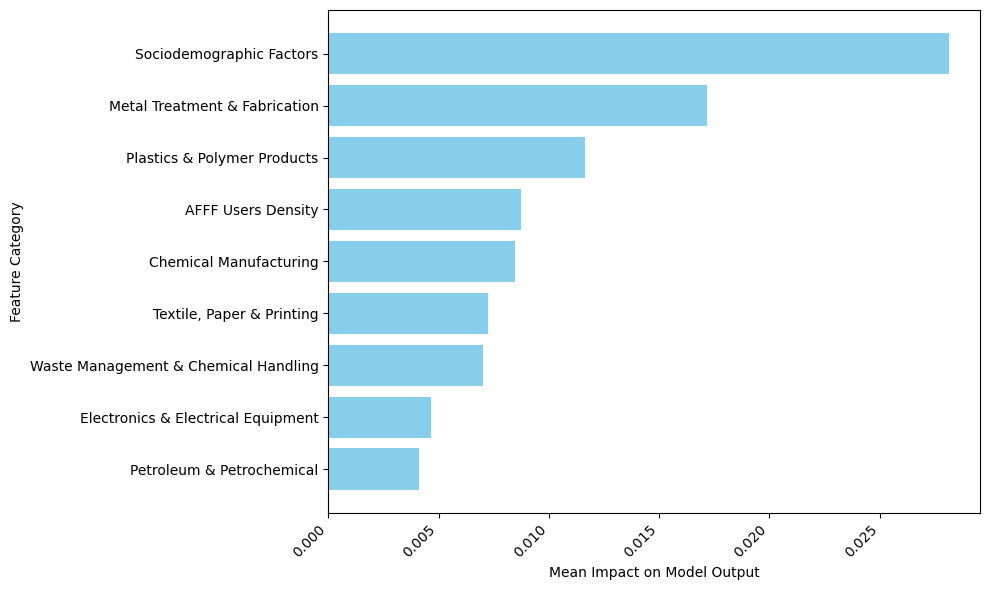

In [ ]:
category_wise_impact = impact_df[['Product_category','Mean Impact']].groupby('Product_category').mean().sort_values(by='Mean Impact', ascending=True).reset_index()
plt.figure(figsize=(10, 6))
plt.barh(category_wise_impact['Product_category'], category_wise_impact['Mean Impact'], color='skyblue')
plt.xlabel('Mean Impact on Model Output')
plt.ylabel('Feature Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.fontsize = 18
plt.show()

In [ ]:
naics_categories[naics_categories['NAICS_Code']==325998]['NAICS_Name']

10    All Other Miscellaneous Chemical Product and P...
Name: NAICS_Name, dtype: object

In [ ]:
naics_categories

,NAICS_Code,NAICS_Name,Product_Category
0,313210,Broadwoven Fabric Mills,"Textile, Paper & Printing"
1,322121,Paper (except Newsprint) Mills,"Textile, Paper & Printing"
2,323111,Commercial Printing (except Screen and Books),"Textile, Paper & Printing"
3,324110,Petroleum Refineries,Petroleum & Petrochemical
4,324191,Petroleum Lubricating Oil and Grease Manufactu...,Petroleum & Petrochemical
5,325199,All Other Basic Organic Chemical Manufacturing,Chemical Manufacturing
6,325211,Plastics Material and Resin Manufacturing,Plastics & Polymer Products
7,325510,Paint and Coating Manufacturing,Chemical Manufacturing
8,325611,Soap and Other Detergent Manufacturing,Chemical Manufacturing
9,325612,Polish and Other Sanitation Good Manufacturing,Chemical Manufacturing


#### Testing Unsupervised modelling

In [ ]:
data = gdf_in_ucmr_model_E.drop(columns=['geometry','Industry_Count','NAME','density'])
data.dropna(inplace=True)
data_scaled = scaler.transform(data.drop(columns=['violation_status','HUC8']).values)

In [ ]:
#Perform tsne on X_train_scaled
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=101)

tsne_results = tsne.fit_transform(data_scaled)
# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
# Add the HUC8 and violation_status for coloring
tsne_df['HUC8'] = data['HUC8'].values
tsne_df['violation_status'] = data['violation_status'].values
# plot the tsne

# plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], cmap='viridis', alpha=0.5)
# Plot TSNE, color by violation_status colummn. Make it using plotly. Give it hover of HUC8 and violation_status
import plotly.express as px
fig = px.scatter(tsne_df, x='TSNE1', y='TSNE2', color='violation_status',
                 hover_data=['HUC8'], title='t-SNE Visualization of HUC8 Data')
fig.update_traces(marker=dict(size=5, opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(legend_title_text='Violation Status')
fig.show()



In [ ]:
# Do KNN clustering on the data_scaled into 2 clusters. Plot the clusters and color by violation status.
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=101)
kmeans.fit(data_scaled)
# plot the clusters


KMeans(n_clusters=2, random_state=101)

In [ ]:
data_scaled_df = pd.DataFrame(data_scaled, columns=data.drop(columns=['violation_status','HUC8']).columns)

In [ ]:
# for i in range(data_scaled.shape[1]):    
#     totpop_impact_df = pd.DataFrame({
#         'Data': data_scaled[:,i],
#         'SHAP_Value': shap_values[:,i,1]
#     })
#     totpop_impact_df['SHAP_Value'] = totpop_impact_df['SHAP_Value'].astype(float)
#     for index, row in totpop_impact_df.iterrows():
#         if row['SHAP_Value'] >= 0:
#             totpop_impact_df.at[index, 'Color'] = 'blue'
#         elif row['SHAP_Value'] < 0:
#             totpop_impact_df.at[index, 'Color'] = 'red'
#     plt.figure(figsize=(8, 8))
#     plt.scatter(totpop_impact_df['Data'], totpop_impact_df['SHAP_Value'], c=totpop_impact_df['Color'], alpha=0.5)
#     plt.xlabel('Scaled Total Population')
#     plt.ylabel('SHAP Value')
#     plt.title(f'{data.columns[i]}')
#     plt.axhline(0, color='black', linestyle='--')
#     plt.fontsize = 14
#     # Set x axis as log
#     # plt.xscale('log')
#     # plt.xlim([-1,1])

## Sending Pushover Notification

In [ ]:
import requests

# Replace these with your actual credentials
user_key = "uqi7ybsbikcszikmgmjxbrc41viq2r"
app_token = "a725zmrgg6req3b3mujav5g1kfk2a6"

message = {
    "token": app_token,
    "user": user_key,
    "title": "Model Training Done",
    "message": "Feature importance ready",
    "priority": 0  # -1=low, 0=normal, 1=high, 2=emergency
}

response = requests.post("https://api.pushover.net/1/messages.json", data=message)

if response.status_code == 200:
    print("Notification sent!")
else:
    print(f"Failed to send notification: {response.status_code}, {response.text}")

Notification sent!


# MODEL F- 10-fold cross validated Random Forest Model trained on Industry + AFFF + Sociodemographics + Land Use Data

In [ ]:
nanda_land_data_2020 = pd.read_csv(f"{cwd}/source_data_files/generated-data-files/nanda_land_data_2020_with_geolocations.csv")
nanda_land_data_2020['geometry'] = nanda_land_data_2020['geometry'].apply(wkt.loads)

In [ ]:
gdf_in_ucmr_model_F = gdf_in_ucmr_model_E.copy()
gdf_in_ucmr_model_F = gpd.GeoDataFrame(gdf_in_ucmr_model_F, geometry='geometry', crs="EPSG:4326")

# Ensure both GeoDataFrames are in the same CRS
nanda_land_data_2020 = gpd.GeoDataFrame(nanda_land_data_2020, geometry='geometry', crs="EPSG:4326")
# Spatial join nanda_land_data_2020 and gdf_in_ucmr_model_F
nanda_land_with_huc8 = gpd.sjoin(
    gdf_in_ucmr_model_F[['HUC8', 'geometry']],
    nanda_land_data_2020,
    how='left',
    predicate='contains',  # or 'contains', but 'within' is better when matching point-in-polygon
)

In [ ]:
nanda_land_grouped = nanda_land_with_huc8.drop(columns=["geometry",'ZCTA','index_right']).groupby("HUC8").mean().reset_index()
gdf_in_ucmr_model_F = gdf_in_ucmr_model_F.merge(nanda_land_grouped, on="HUC8", how="left", suffixes=('', '_land'))


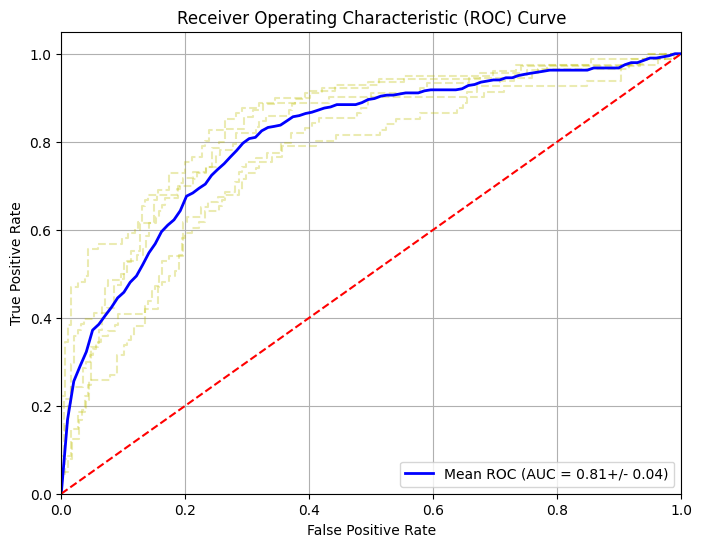

Mean accuracy:  0.7597758441046436 +/- 0.037210567950555065


In [ ]:
X = gdf_in_ucmr_model_F.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
y = gdf_in_ucmr_model_F['violation_status'].values
kf = KFold(n_splits=5, shuffle=True)
mean_fpr = np.linspace(0, 1, 100)
scaler = StandardScaler()

roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []

model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')
# Perform K-fold cross-validation
for train_index, test_index in kf.split(X):
    # print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1, drop_intermediate=False, )
    roc_auc = auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)
    accuracy_list.append(accuracy)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_list)

plt.figure(figsize=(8, 6))
for i, roc_auc in enumerate(roc_auc_list):
    plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))


# Hyperparameter Optimization - Model E

In [ ]:
# X = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
# y = gdf_in_ucmr_model_E['violation_status'].values

# for random_state_val in range(0,150):

#     kf = KFold(n_splits=5, shuffle=True) 
#     mean_fpr = np.linspace(0, 1, 100)
#     scaler = StandardScaler()

#     roc_auc_list, accuracy_list, fpr_list, tpr_list, tprs   = [], [], [], [], []

#     model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=random_state_val)
#     # Perform K-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         # print("TRAIN:", train_index, "TEST:", test_index)
#         X_train, X_test = X[train_index], X[test_index]
#         y_train, y_test = y[train_index], y[test_index]
#         scaler.fit(X_train)
#         X_train_scaled = scaler.transform(X_train)
#         X_test_scaled = scaler.transform(X_test)
        
#         model.fit(X_train_scaled, y_train)
#         y_pred = model.predict(X_test_scaled)
#         y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

#         accuracy = accuracy_score(y_test, y_pred)
#         conf_matrix = confusion_matrix(y_test, y_pred)
#         from sklearn.metrics import roc_curve, auc
#         fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1, drop_intermediate=False, )
#         roc_auc = auc(fpr, tpr)
#         fpr_list.append(fpr)
#         tpr_list.append(tpr)
#         roc_auc_list.append(roc_auc)
#         accuracy_list.append(accuracy)
#         interp_tpr = np.interp(mean_fpr, fpr, tpr)
#         interp_tpr[0] = 0.0
#         tprs.append(interp_tpr)
#     mean_tpr = np.mean(tprs, axis=0)
#     mean_tpr[-1] = 1.0
#     mean_auc = auc(mean_fpr, mean_tpr)
#     std_auc = np.std(roc_auc_list)

#     if mean_auc > 0.8:

#         plt.figure(figsize=(8, 6))
#         for i, roc_auc in enumerate(roc_auc_list):
#             plt.plot(fpr_list[i], tpr_list[i], '--y', alpha=0.3)

#         plt.plot(mean_fpr, mean_tpr, color='b', label=f"Mean ROC (AUC = {mean_auc:.2f}+/- {std_auc:.2f})", lw=2)
#         plt.plot([0, 1], [0, 1], color='red', linestyle='--')
#         plt.xlim([0.0, 1.0])
#         plt.ylim([0.0, 1.05])
#         plt.xlabel('False Positive Rate')
#         plt.ylabel('True Positive Rate')
#         plt.title('Receiver Operating Characteristic (ROC) Curve')
#         plt.legend(loc='lower right')
#         plt.grid()
#         plt.show()

#         print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))
#     else:
#         print(f"Skipping random_state {random_state_val} due to low AUC: {mean_auc:.2f} +/- {std_auc:.2f}")
#         continue


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Example data
X = gdf_in_ucmr_model_E.drop(columns=['HUC8', 'geometry','Industry_Count','NAME','density', 'violation_status']).values
y = gdf_in_ucmr_model_E['violation_status'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Model
rf = RandomForestClassifier(random_state=101)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',  # or use make_scorer if custom
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Evaluate on test set
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_prob)
print("Test ROC AUC:", test_auc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 3/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.764 total time=   0.2s
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.820 total time=   0.2s
[CV 5/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.813 total time=   0.1s
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.794 total time=   0.2s
[CV 4/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.814 total time=   0.3s
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.799 total time=   0.4s
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.796 total time=   0.2s
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.8

In [ ]:
# Best model
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Evaluate on test set
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_prob)
print("Test ROC AUC:", test_auc)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Test ROC AUC: 0.8002055762559424


# Figure Cell


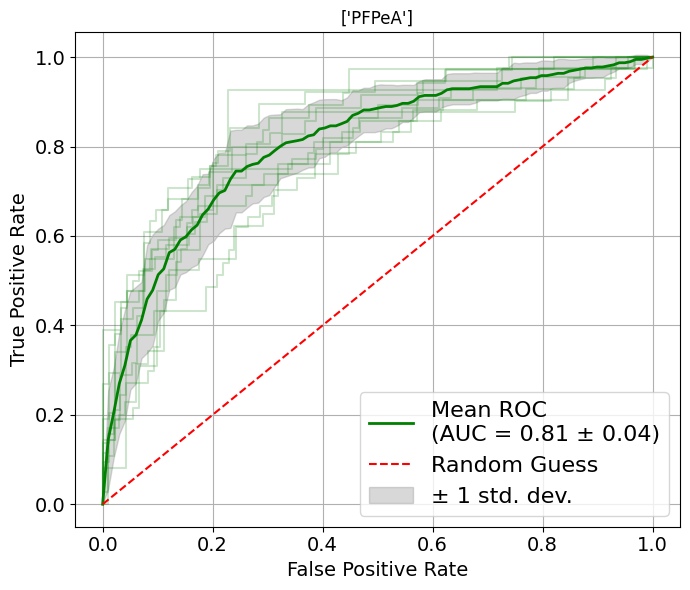

Mean accuracy:  0.7747671417349344 +/- 0.02631690747109695


In [ ]:
tpr_list, fpr_list, mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc, accuracy_list = model_E_results

# Plot
plt.figure(figsize=(7, 6))

# Individual ROC curves
for i in range(len(tpr_list)):
    plt.plot(fpr_list[i], tpr_list[i],
            color='green', alpha=0.2)

# Mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='green', label=f'Mean ROC \n(AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2)

# Random classifier line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

# Shaded std dev area
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='grey', alpha=0.3, label='± 1 std. dev.')

# Labels and legend
plt.xlabel("False Positive Rate", fontsize = 14)
plt.ylabel("True Positive Rate", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(contaminants_of_interest)
# plt.title(f"ROC Curve (5-Fold Cross-Validation)_{random_state_val}")
plt.legend(loc="lower right")
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Mean accuracy: ", np.mean(accuracy_list),'+/-', np.std(accuracy_list))


In [ ]:
# print the value of mean FPR when mean TPR is 0.8
mean_tpr = np.array(mean_tpr)
mean_fpr = np.array(mean_fpr)
mean_tpr_80_index = np.where(mean_tpr >= 0.8)[0][0]
mean_fpr_at_80_tpr = mean_fpr[mean_tpr_80_index]
print(f"{contaminant} Mean FPR when Mean TPR is 0.8: {mean_fpr_at_80_tpr:.4f}")

PFPeA Mean FPR when Mean TPR is 0.8: 0.3232


In [ ]:
import requests

# Replace these with your actual credentials
user_key = "uqi7ybsbikcszikmgmjxbrc41viq2r"
app_token = "a725zmrgg6req3b3mujav5g1kfk2a6"

message = {
    "token": app_token,
    "user": user_key,
    "title": "Hello from Python",
    "message": "bye",
    "priority": 0  # -1=low, 0=normal, 1=high, 2=emergency
}

response = requests.post("https://api.pushover.net/1/messages.json", data=message)

if response.status_code == 200:
    print("Notification sent!")
else:
    print(f"Failed to send notification: {response.status_code}, {response.text}")

Notification sent!
